In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sunpy.visualization.colormaps as sunpycm
import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

from sdofmv2.core import MAE, MAE_old, SDOMLDataModule
from sdofmv2.utils import ALL_WAVELENGTHS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA.yaml"
    )

cfg_old = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA_old.yaml"
)

In [3]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()


data_module_for_old = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg_old.data.sdoml.base_directory, 
        cfg_old.data.sdoml.sub_directory.hmi
    ) if cfg_old.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_old.data.sdoml.base_directory,
        cfg_old.data.sdoml.sub_directory.aia,
    ) if cfg_old.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_old.data.sdoml.components,
    wavelengths=cfg_old.data.sdoml.wavelengths,
    ions=cfg_old.data.sdoml.ions,
    frequency=cfg_old.data.sdoml.frequency,
    batch_size=cfg_old.model.misc.batch_size,
    num_workers=cfg_old.data.num_workers,
    val_months=cfg_old.data.month_splits.val,
    test_months=cfg_old.data.month_splits.test,
    holdout_months=cfg_old.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg_old.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg_old.data.min_date,
    max_date=cfg_old.data.max_date,
    num_frames=cfg_old.model.mae.num_frames,
    drop_frame_dim=cfg_old.data.drop_frame_dim,
    apply_mask=cfg_old.data.sdoml.apply_mask,
    precision=cfg_old.experiment.precision,
    normalization=cfg_old.data.sdoml.normalization,
)
data_module_for_old.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-04-20 19:46:05.940 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-20 19:46:05.941 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-20 19:46:05.941 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-20 19:46:05.942 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-20 19:46:05.942 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-20 19:46:05.942 | INFO     | sdofmv2.core.datamodu

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.
[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-04-20 19:46:06.151 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-04-20 19:46:06.152 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-04-20 19:46:06.153 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-04-20 19:46:06.153 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-04-20 19:46:06.153 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:997 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-04-20 19:46:06.153 | INFO     | sdofmv

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [4]:
wavelenghs = ALL_WAVELENGTHS
wavelenghs.sort()

wave_val_list = []
for wave in wavelenghs:
    val = wave[:-1]
    wave_val_list.append(int(val))

wave_arr = np.array(wave_val_list)
sort_ids = np.argsort(wave_arr)

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
]

In [5]:
ckpt_dir = "../../assets/checkpoints/backbone/"
model = MAE.load_from_checkpoint(
    # checkpoint_path= ckpt_dir + "AIA/id_par5tzyo_mae_epoch=9-val_loss=0.08.ckpt",
    checkpoint_path=ckpt_dir+"AIA/id_igwdm7mx_mae_epoch=18-val_loss=0.02.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

model_old = MAE_old.load_from_checkpoint(
    checkpoint_path=ckpt_dir + "pretrained_mae_e128.ckpt", 
    map_location="cpu",
    weights_only=False,
    optimizer_dict=None,
    scheduler_dict=None,
)
lgr_logger.info(f"masking ratio of sdofmv1: {model_old.masking_ratio}")

2026-04-20 19:46:13.682 | INFO     | __main__:<module>:7 - masking ratio of sdofmv2: 0.0
2026-04-20 19:46:15.556 | INFO     | __main__:<module>:16 - masking ratio of sdofmv1: 0.5


In [6]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

x_set_old = torch.cat([data_module_for_old.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts_old = [pd.to_datetime(data_module_for_old.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00')]


In [7]:
model.eval()

with torch.no_grad():
    output = model(x_set)
    output_old = model_old(x_set_old)

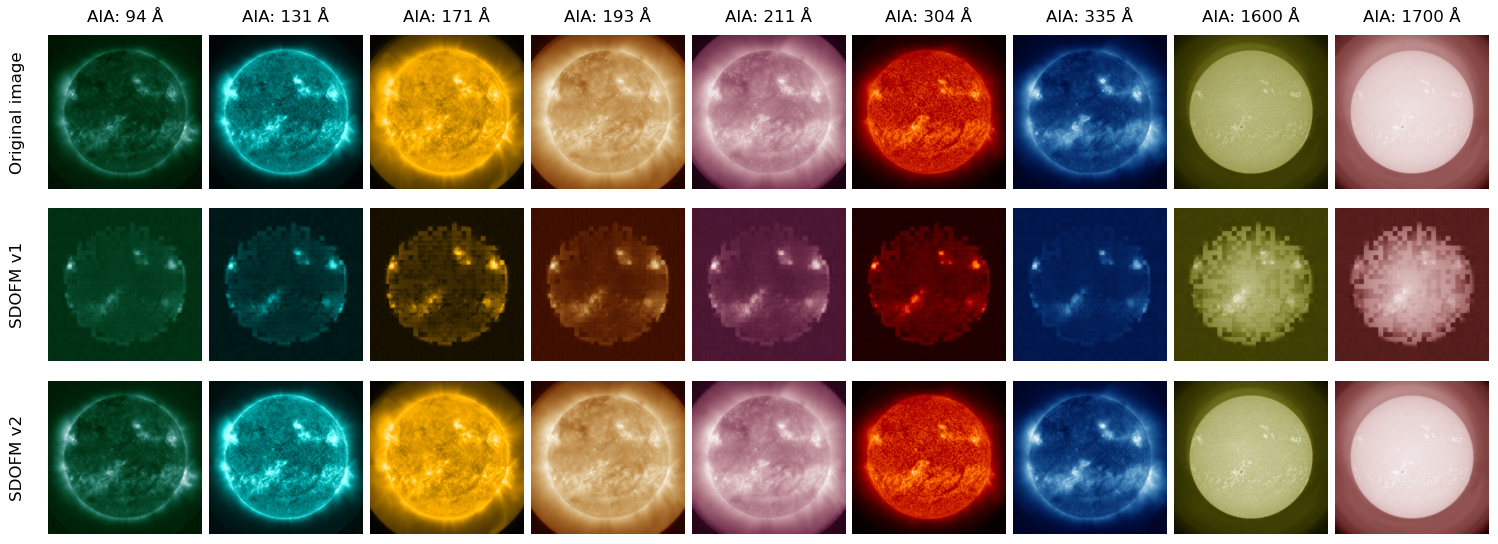

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=9, figsize=(16, 6))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]


for i, col in enumerate(sort_ids):
    
    axes[0][i].set_title(f"AIA: {ch_info[col]} Å", fontsize=12, pad=10)
    # --- Row 0: Original Image ---
    axes[0][i].imshow(x_set[0, col, 0, :, :], cmap=cms[col])
    # --- Row 1: SDOFM v1 ---
    # axes[1][i].imshow(output_old[1][0, col, 0, :, :] * model.limb_mask, cmap=cms[col])
    axes[1][i].imshow(output_old[1][0, col, 0, :, :], cmap=cms[col])
    # --- Row 2: SDOFM v2 ---
    # axes[2][i].imshow(output[0][0, col, 0, :, :] * model.limb_mask, cmap=cms[col])
    axes[2][i].imshow(output[0][0, col, 0, :, :], cmap=cms[col])

row_info = ["Original image", "SDOFM v1", "SDOFM v2"]

for row_idx in range(3):
    axes[row_idx][0].text(
        -0.2, 0.5,              # Negative x moves it to the left
        f"{row_info[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=12, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

plt.savefig(f"SDOFMv2_results_per_wavelengh_{ts[0]}.pdf", dpi=300, bbox_inches="tight")
plt.show()

TypeError: unsupported operand type(s) for *: 'Tensor' and 'NoneType'

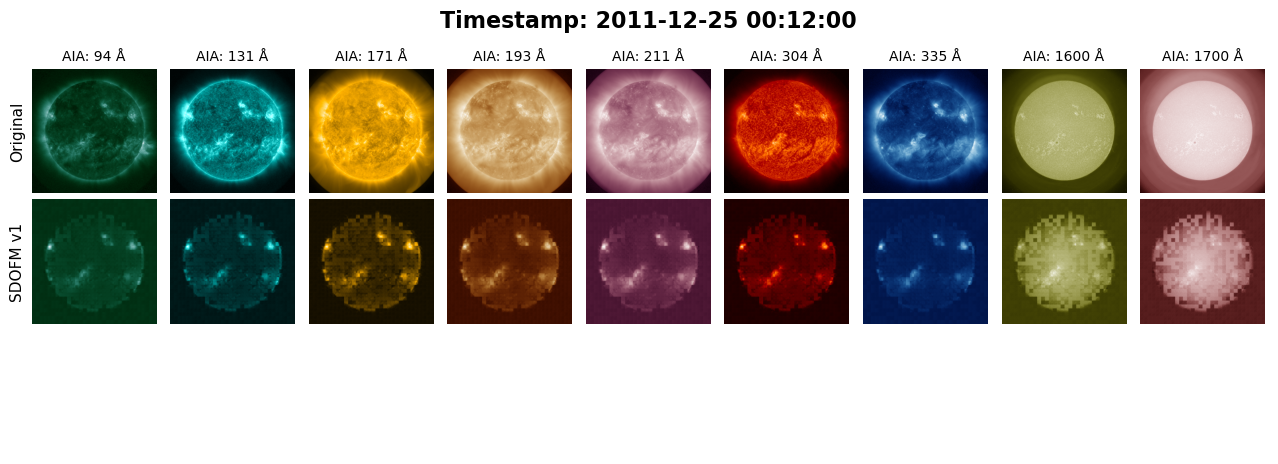

In [9]:
# Data setup (assuming your variables x_set, output, cms, sort_ids, ts exist)
ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]
row_labels = ["Original", "SDOFM v1", "SDOFM v2"]

fig = plt.figure(figsize=(16, 18))
outer_grid = gridspec.GridSpec(len(ts), 1, hspace=0.3, figure=fig)

for t_i, timestamp in enumerate(ts):
    inner_grid = gridspec.GridSpecFromSubplotSpec(3, 9, 
                                                  subplot_spec=outer_grid[t_i], 
                                                  wspace=0.05, hspace=0.05)
    
    # --- Add Timestamp Title ---
    ax_header = plt.Subplot(fig, outer_grid[t_i])
    fig.add_subplot(ax_header)
    ax_header.set_title(f"Timestamp: {timestamp}", fontsize=16, weight='bold', pad=30)
    ax_header.axis('off') # Hide the axis lines, just keep the title

    for row_idx in range(3): # Loop: Original, v1, v2
        for col_idx, ch_id in enumerate(sort_ids):
            
            # Create the subplot in the inner grid
            ax = plt.Subplot(fig, inner_grid[row_idx, col_idx])
            fig.add_subplot(ax)
            
            # Turn off spines/ticks for clean look
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # --- Plotting Logic ---
            if row_idx == 0:
                img_data = x_set[t_i, ch_id, 0, :, :]

                if t_i == 0:
                    ax.set_title(f"AIA: {ch_info[ch_id]} Å", fontsize=10)
                    
            elif row_idx == 1:
                # SDOFM v1
                img_data = output_old[1][t_i, ch_id, 0, :, :]
            elif row_idx == 2:
                # SDOFM v2
                img_data = output[0][t_i, ch_id, 0, :, :] * model.limb_mask
            
            ax.imshow(img_data, cmap=cms[ch_id])

            if col_idx == 0:
                ax.set_ylabel(row_labels[row_idx], fontsize=11, rotation=90, labelpad=5)

plt.savefig(f"SDOFMv2_Refined_{ts}.pdf", dpi=300, bbox_inches="tight")
plt.show()